## PRACTICA NLP FERNANDO AMALFITANO





# **1.   DESCARGA Y EXPLORACIÓN DEL CORPUS**







In [ ]:
# Instalación de librerías
!pip install gensim
!pip install stop-words
!pip install spacy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 2.1 MB/s eta 0:00:00


In [53]:
# Importamos las librerías que vamos a necesitar en el proyecto:
import random
import numpy as np
import pandas as pd

from nltk import ngrams # Exploración
from nltk.probability import FreqDist # Exploración
from stop_words import get_stop_words # Preprocesado
import unicodedata # Preprocesado
import re # Preprocesado
from wordcloud import WordCloud
from nltk import ngrams
from nltk.probability import FreqDist
import spacy
import re
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split # Modelado
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer # Modelado
from sklearn.feature_selection import chi2 # Reporte
from sklearn.linear_model import LogisticRegression # Reporte
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, precision_recall_curve # Reporte

import matplotlib.pyplot as plt

In [ ]:
# Carga del archivo 'reviews_Sports_and_Outdoors_5.json.gz' que contiene los datos con los cuales trabajares:
from google.colab import files

uploaded = files.upload()

Saving reviews_Sports_and_Outdoors_5.json.gz to reviews_Sports_and_Outdoors_5.json.gz


In [ ]:
# Aquí lo que hago es leer el archivo comprimido y convierto cada reseña
# en un diccionario y las guardo en una lista.

import gzip
import json

reviews = []

with gzip.open("reviews_Sports_and_Outdoors_5.json.gz", "rt", encoding="utf-8") as f:
    for line in f:
        reviews.append(json.loads(line))

In [ ]:
# Ejemplo del primer elemento:
reviews[0]

{'reviewerID': 'AIXZKN4ACSKI',
 'asin': '1881509818',
 'reviewerName': 'David Briner',
 'helpful': [0, 0],
 'reviewText': 'This came in on time and I am veru happy with it, I haved used it already and it makes taking out the pins in my glock 32 very easy',
 'overall': 5.0,
 'summary': 'Woks very good',
 'unixReviewTime': 1390694400,
 'reviewTime': '01 26, 2014'}

In [ ]:
# Con esta función creo un DataFrame con dos columnas:
# Texto y target
import pandas as pd

reviews_text = []
reviews_rating = []

for review in reviews:
    reviews_text.append(review.get("reviewText"))
    reviews_rating.append(review.get("overall"))

df = pd.DataFrame({
    "review": reviews_text,
    "rating": reviews_rating
})

df.dropna(subset=["review", "rating"], inplace=True)
df.reset_index(drop=True, inplace=True)

df.head()

,review,rating
0,This came in on time and I am veru happy with ...,5.0
1,I had a factory Glock tool that I was using fo...,5.0
2,If you don't have a 3/32 punch or would like t...,4.0
3,This works no better than any 3/32 punch you w...,4.0
4,I purchased this thinking maybe I need a speci...,4.0


In [ ]:
# Analizo la dimension del DataFrame:
# 296337 filas y las 2 columnas creadas antes.
df.shape

(296337, 2)

In [ ]:
# Cardinalidad del vocabulario (sin preprocesar)
vocabulario = set()

for review in df["review"]:
    palabras = re.findall(r"[a-zA-Z]+", review.lower())
    vocabulario.update(palabras)

print("Cardinalidad del vocabulario:", len(vocabulario))

Cardinalidad del vocabulario: 109352


In [ ]:
# Aquí puedo ver la longuitud media de cada review:
df["num_words"] = df["review"].apply(lambda x: len(x.split()))

print(df["num_words"].describe())

count    296337.000000
mean         87.165157
std         109.464290
min           0.000000
25%          31.000000
50%          53.000000
75%         100.000000
max        5771.000000
Name: num_words, dtype: float64


In [ ]:
# Analizo el numero de review por numero de estrellas:
df["rating"].value_counts().sort_index()

,count
rating,
1.0,9045
2.0,10204
3.0,24071
4.0,64809
5.0,188208


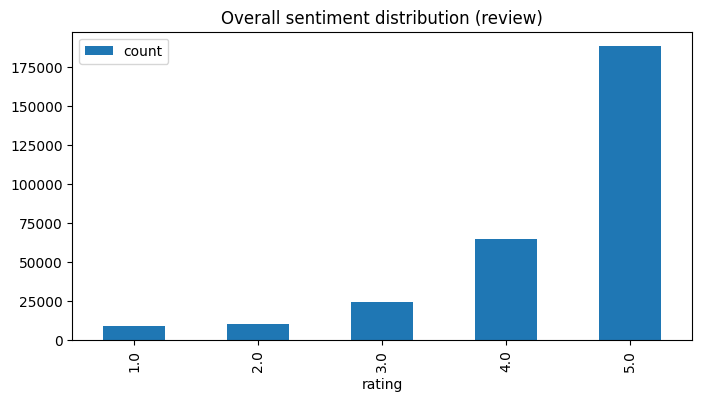

In [ ]:
# Histograma de review por numero de estrellas en la review
aux_df = pd.DataFrame(df['rating'].value_counts(sort=False).sort_index())
aux_df = aux_df.plot(kind='bar', title='Overall sentiment distribution (review)', figsize=(8, 4))

In [ ]:
# Con esta función añado una columna llamada 'seniment_label'
# que asigna el valor '0' a los rating < 3 (sentimiento negativo)
# y '1' a los rating > 3 (sentimiento positivo)
def label_sentiment(row):
    if int(row['rating']) < 3:
        return 0
    else:
        return 1
df['sentiment_label'] = df.apply(lambda row: label_sentiment(row), axis=1)
df

,review,rating,num_words,sentiment_label
0,This came in on time and I am veru happy with ...,5.0,30,1
1,I had a factory Glock tool that I was using fo...,5.0,55,1
2,If you don't have a 3/32 punch or would like t...,4.0,49,1
3,This works no better than any 3/32 punch you w...,4.0,34,1
4,I purchased this thinking maybe I need a speci...,4.0,49,1
...,...,...,...,...
296332,This is a water bottle done right. It is a ver...,5.0,512,1
296333,If you're looking for an insulated water bottl...,5.0,204,1
296334,"This Hydracentials Sporty 25 OZ, double insula...",5.0,139,1
296335,As usual I received this item free in exchange...,5.0,72,1


sentiment_label
0     19249
1    277088
Name: count, dtype: int64


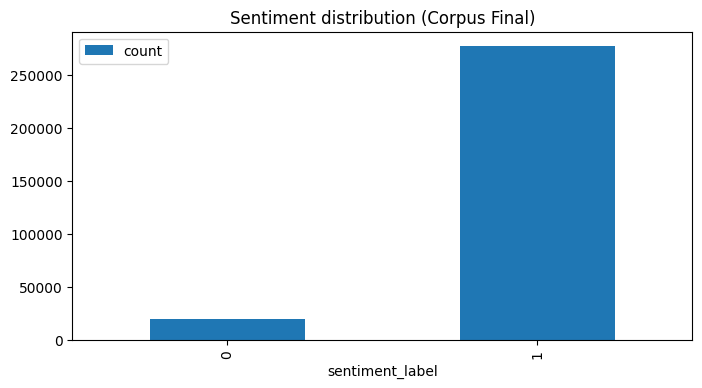

In [ ]:
# Número de review positivas y negativas.
# Histograma de review positivas y negativas
print(df["sentiment_label"].value_counts().sort_index())

aux_df = pd.DataFrame(df['sentiment_label'].value_counts(sort=False).sort_index())
aux_df = aux_df.plot(kind='bar', title='Sentiment distribution (Corpus Final)', figsize=(8, 4))

 Como podemos observar, nuestro dataframe está desbalanciado. Existe muchas mas review positivas que negativas.

 A partir de aquí decido realizar un analisis con nubes de palabras. Con esta técnica consigo ver que palabras frecuentan en los textos de las reseñas negativas y positivas.
 Una vez realizado el analisis, puedo tomar la desición sobre que palabras incorporar al conjunto de stop words.

In [ ]:
# Creo una variable la cual utilizaré mas tarde.
# A esta variable le asigno todas las stop words del Ingles y
# descarto palabras como 'no', 'not', 'never' que me pueden cambiar
# el sentimiento de una frase.

english_stop_words = set(get_stop_words("en"))

english_stop_words.discard("no")
english_stop_words.discard("not")
english_stop_words.discard("never")

# Aqui me aseguro que no estan en la variable.
print("no" in english_stop_words)
print("not" in english_stop_words)
print("never" in english_stop_words)

False
False
False


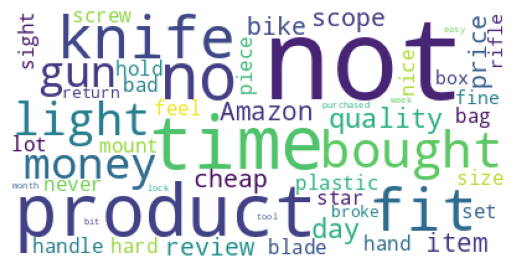

In [ ]:
# Analizo las palabras que aparecen mas veces en los textos de
# reseñas negativas

sentiment = 0

combined_text = " ".join(df.loc[df['sentiment_label'].isin([sentiment]), 'review'])

wc = WordCloud(background_color='white', max_words=50,
        stopwords = english_stop_words)

plt.imshow(wc.generate(combined_text))
plt.axis('off')
plt.show()

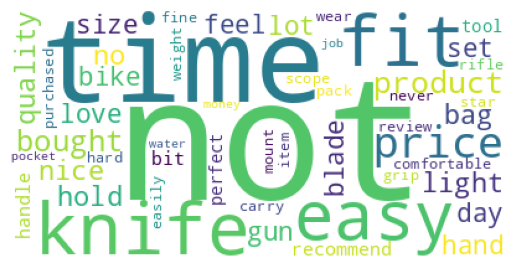

In [ ]:
# Analizo las palabras que aparecen mas veces en los textos de
# reseñas positivas

sentiment = 1

combined_text = " ".join(df.loc[df['sentiment_label'].isin([sentiment]), 'review'])

wc = WordCloud(background_color='white', max_words=50,
        stopwords = english_stop_words)

plt.imshow(wc.generate(combined_text))
plt.axis('off')
plt.show()

In [ ]:
# Elimino palabras que aparecen tanto en reseñas positivas como negativas, ya que no ayudan
# al modelo
english_stop_words=english_stop_words.union(set(["time","knife","fit","product","bought", "time","light"]))

Se eliminan las stop words para resaltar los términos con mayor contenido semántico.

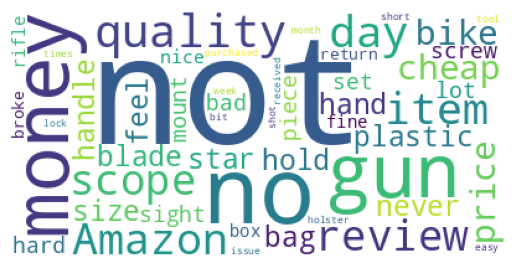

In [ ]:
sentiment = 0

combined_text = " ".join(df.loc[df['sentiment_label'].isin([sentiment]), 'review'])

wc = WordCloud(background_color='white', max_words=50,
        stopwords = english_stop_words)

plt.imshow(wc.generate(combined_text))
plt.axis('off')
plt.show()

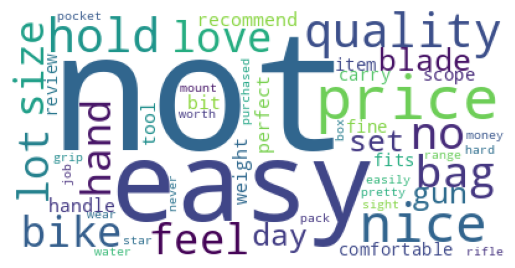

In [ ]:
sentiment = 1

combined_text = " ".join(df.loc[df['sentiment_label'].isin([sentiment]), 'review'])

wc = WordCloud(background_color='white', max_words=50,
        stopwords = english_stop_words)

plt.imshow(wc.generate(combined_text))
plt.axis('off')
plt.show()

Tras volver a analizar las nubes de palabras, considero que no debo eliminar ninguna palabra mas. "Not" aparece tanto en reseñas positivas como en las negativas, pero no voy a eliminarla porque puede cambiar el sentimiento de una frase.

In [ ]:
# Analizo los unigramas y bigramas

tokens = []

for review in df["review"]:
    palabras = re.findall(r"[a-zA-Z]+", review.lower())

    palabras = [
        p
        for p in palabras
        if p not in english_stop_words
    ]

    tokens.extend(palabras)

# Unigramas
unigramas = FreqDist(tokens)

print("20 unigramas más frecuentes")
print(unigramas.most_common(20))

# Bigramas
bigramas = list(ngrams(tokens, 2))

fd_bigramas = FreqDist(bigramas)

print("\n20 bigramas más frecuentes")
print(fd_bigramas.most_common(20))

20 unigramas más frecuentes
[('not', 176330), ('no', 61503), ('easy', 47885), ('price', 46305), ('nice', 41569), ('quality', 40972), ('bike', 38373), ('bag', 36505), ('size', 30155), ('recommend', 29856), ('water', 28534), ('blade', 28092), ('bit', 27573), ('gun', 25780), ('perfect', 24421), ('love', 23651), ('set', 23365), ('fits', 23131), ('pretty', 22693), ('handle', 22226)]

20 bigramas más frecuentes
[(('highly', 'recommend'), 7484), (('easy', 'install'), 4500), (('water', 'bottle'), 3850), (('red', 'dot'), 3720), (('heavy', 'duty'), 3486), (('not', 'bad'), 2967), (('highly', 'recommended'), 2941), (('cold', 'steel'), 2480), (('stainless', 'steel'), 2426), (('worth', 'money'), 2400), (('no', 'issues'), 2383), (('fits', 'perfectly'), 2341), (('no', 'complaints'), 2188), (('road', 'bike'), 2181), (('mountain', 'bike'), 2109), (('not', 'not'), 2105), (('razor', 'sharp'), 2030), (('sleeping', 'bag'), 1964), (('sharp', 'box'), 1743), (('customer', 'service'), 1669)]


 Conclusiones tras la exploración:

 *   El corpus está claramente desbalanceado hacia las reseñas positivas.
 *   La longitud media de las reseñas es de 87 palabras.
 *   Las nubes de palabras muestran diferencias entre reseñas positivas y negativas.



# **2. ETAPA DE PREPROCESADO**

Deicido seleccionar un subconjunto de 20.000 reseñas con el objetivo de reducir el tiempo de preprocesado y entrenamiento de los modelos, manteniendo al mismo tiempo un tamaño suficientemente representativo para obtener resultados fiables. Además, se construye un conjunto balanceado de 10.000 reseñas positivas y 10.000 negativas para evitar el sesgo producido por el fuerte desbalance presente en el corpus original.

In [ ]:

df_pos = df[df["sentiment_label"] == 1]
df_neg = df[df["sentiment_label"] == 0]

df2 = pd.concat([
    df_pos.sample(n=10000, random_state=42),
    df_neg.sample(n=10000, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# Analizo el nuevo subset:
print(df2["sentiment_label"].value_counts())

sentiment_label
0    10000
1    10000
Name: count, dtype: int64


In [ ]:
# Función de preprocesamiento:

def preprocess_reviews(texts):
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

    docs = nlp.pipe(texts, batch_size=1000)

    negaciones = {"no", "not", "never"}

    review_clean = []

    for doc in docs:

        tokens = []

        for token in doc:

            if token.text.lower() in negaciones:
                tokens.append(token.lemma_.lower())

            elif not token.is_stop and not token.is_punct and token.is_alpha:
                tokens.append(token.lemma_.lower())

        review_clean.append(" ".join(tokens))

    return review_clean


In [ ]:
# Aquí aplico la función creada anteriormente a todas las reviews de
# mi subset y creo la columna "review_clean" dentro del subset con
# todo el texto de las reviews preprocesado.
df2["review_clean"] = preprocess_reviews(df2["review"])

In [ ]:
df2["review_clean"]

,review_clean
0,thing not worth box ship golf training aid mea...
1,easy install easy adjust recommend product come
2,roomy case adequate padding protect remington ...
3,get play fun stick everytime throw come little...
4,negative vocabulary talk t mobile thesaurus re...
...,...
19995,buy originally ruger mkiii great minute dot st...
19996,buy tire display image year bell make smart ha...
19997,replace worn brake pad pretty easy video know ...
19998,knife wonderful price block massive hunk plast...


In [ ]:
# En esta parte, creo un modelo Word2Vec a partir de tus reseñas ya preprocesadas.
# Es decir, aprende una representación numérica (vector) de cada palabra según
# el contexto en el que aparece.
sentences = [
    review.split()
    for review in df2["review_clean"]
]

modelo_w2v = Word2Vec(
    sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    seed=42
)

In [ ]:
palabras = [
    "good",
    "great",
    "bad",
    "quality",
    "product"
]

for palabra in palabras:
    if palabra in modelo_w2v.wv:
        print("\n", palabra)
        print(modelo_w2v.wv.most_similar(palabra, topn=10))


 good
[('okay', 0.7507572770118713), ('great', 0.7448194622993469), ('decent', 0.7289320826530457), ('well', 0.714713990688324), ('reasonable', 0.6978073120117188), ('excellent', 0.696077287197113), ('fantastic', 0.6935616135597229), ('amazing', 0.6879879236221313), ('ok', 0.6823034286499023), ('beat', 0.6784086227416992)]

 great
[('good', 0.7448194026947021), ('awesome', 0.7256895303726196), ('excellent', 0.7170618176460266), ('fantastic', 0.7057181596755981), ('reasonable', 0.6832859516143799), ('perfect', 0.6814820766448975), ('fine', 0.6783432364463806), ('okay', 0.6779927015304565), ('amazing', 0.6761839389801025), ('nice', 0.6709942817687988)]

 bad
[('horrible', 0.7779020071029663), ('terrible', 0.7600760459899902), ('know', 0.7509434223175049), ('ok', 0.7245619893074036), ('trust', 0.7162124514579773), ('stupid', 0.7038915157318115), ('complain', 0.6979669332504272), ('mention', 0.6761338710784912), ('believe', 0.6629427075386047), ('ill', 0.6597768664360046)]

 quality
[('va

Se han seleccionado cinco palabras representativas del corpus y se han obtenido sus diez palabras más similares mediante Word2Vec. Los resultados muestran que el modelo aprende relaciones semánticas entre términos, agrupando palabras con significados próximos dentro del contexto de las reseñas.**

# Visualizar Word2Vec en 2 dimensiones
Ahora mismo tenemos un vector de 100 dimensiones y queremos reducirlo a 2 dimensiones para poder visualizarlo en un grafico

In [ ]:
modelo_w2v.wv["good"]

array([ 0.3077751 , -0.00648959, -0.12939097,  0.23797135,  0.39349654,
        0.30115846,  0.08377472, -0.05029394, -0.24248648, -0.379571  ,
       -1.4074775 , -0.1405754 , -0.27357748, -0.06731546, -0.05664841,
        0.5418697 ,  0.49448782, -0.55251557, -0.58235425, -1.0139205 ,
        0.03882495,  0.4348583 ,  1.350774  ,  0.53328615,  1.174114  ,
        1.6288013 ,  0.24675266,  0.37932017, -0.2068021 , -0.1295171 ,
        0.01846131,  0.31506175,  0.78731465, -0.4781266 ,  0.06322181,
       -0.31339818,  1.0150818 , -1.2385837 ,  0.5237709 ,  1.0209162 ,
        0.88736993, -0.07974681,  0.15705621, -1.218806  ,  0.9849409 ,
        0.3389435 ,  0.13792576,  0.4648377 ,  0.8034998 ,  0.21094888,
        0.12367146,  0.02204218, -0.6093217 , -0.09496027,  0.28721884,
        0.8823012 , -0.09219645,  0.2698363 ,  0.27273613,  0.01589831,
        0.08055003, -0.02956782, -1.0329888 ,  0.0377952 ,  0.19980232,
        0.6861516 ,  0.24498287,  0.04296517, -0.84450763, -0.14

In [ ]:
palabras_plot = []

palabras = [
    "good",
    "great",
    "bad",
    "quality",
    "product"
]

for palabra in palabras:
    if palabra in modelo_w2v.wv:
        palabras_plot.append(palabra)

        similares = modelo_w2v.wv.most_similar(
            palabra,
            topn=10
        )

        for sim, _ in similares:
            palabras_plot.append(sim)

# quitar duplicados
palabras_plot = list(set(palabras_plot))

In [ ]:
vectores = [
    modelo_w2v.wv[palabra]
    for palabra in palabras_plot
]

In [ ]:
pca = PCA(n_components=2)

vectores_2d = pca.fit_transform(vectores)

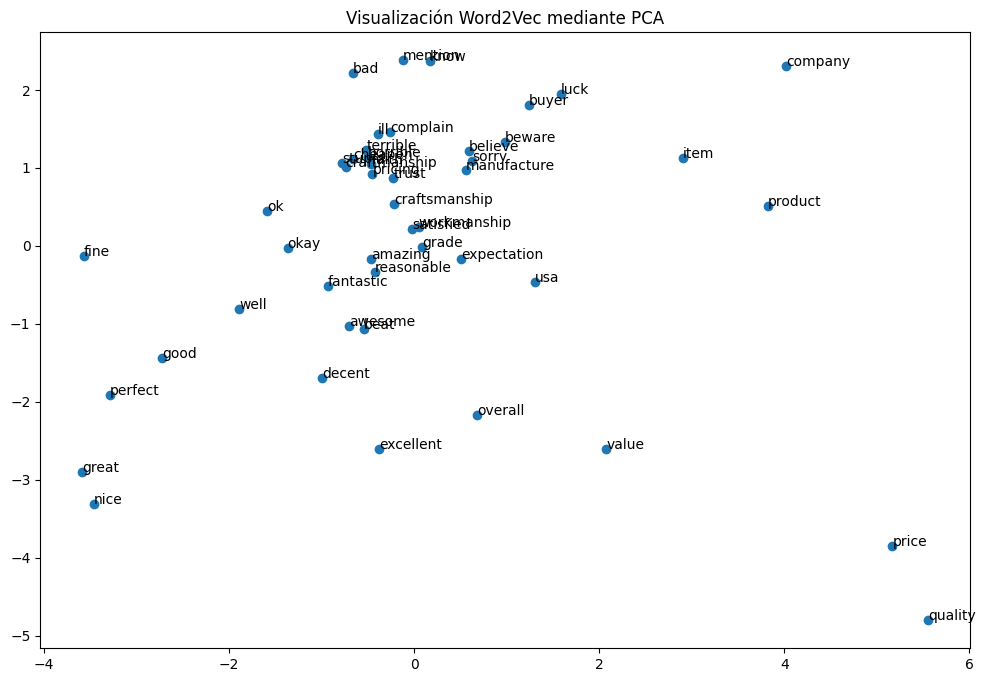

In [ ]:
#Visualización en 2 dimensiones de algunos word embeddings calculados con Word2Vec:
plt.figure(figsize=(12,8))

plt.scatter(
    vectores_2d[:,0],
    vectores_2d[:,1]
)

for i, palabra in enumerate(palabras_plot):
    plt.annotate(
        palabra,
        (vectores_2d[i,0], vectores_2d[i,1])
    )

plt.title("Visualización Word2Vec mediante PCA")
plt.show()

# **3. ENTRENAMIENTO Y TEST**

 A continuación, utilizo TF-IDF para transformar las reseñas de texto en una representación numérica.

 Aunque Word2Vec proporciona representaciones densas del texto, para la tarea de clasificación se emplea TF-IDF debido a que suele ofrecer mejores resultados con modelos lineales

Cada reseña queda representada mediante un vector numérico que contiene la importancia de los términos presentes en ella. Esta representación permitirá entrenar modelos supervisados de clasificación binaria.


In [ ]:
# Analizo la cardinalidad del vocabulario tras el preprocesado:
vocabulario_preprocesado = set()

for review in df2["review_clean"]:
    palabras = review.split()
    vocabulario_preprocesado.update(palabras)

print("Cardinalidad del vocabulario después del preprocesado:", len(vocabulario_preprocesado))

Cardinalidad del vocabulario después del preprocesado: 23984


In [ ]:
# -Se limita el vocabulario a las 5000 características más relevantes
# para reducir la dimensionalidad.
# -min_df=5 elimina palabras muy poco frecuentes.
# -max_df=0.8 elimina términos demasiado frecuentes que aportan poca
# información discriminativa.
# -Se utilizan unigramas y bigramas para capturar tanto palabras
# individuales como expresiones frecuentes.
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df2["review_clean"])

y = df2["sentiment_label"]

In [ ]:
# División entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Modelo 1: Logistic Regression

modelo_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(X_train, y_train)



LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
# Modelo 2: Multinomial Naive Bayes

modelo_nb = MultinomialNB()

modelo_nb.fit(X_train, y_train)

y_pred_nb = modelo_nb.predict(X_test)



# **4. MÉTRICAS Y CONCLUSIONES**



*   Resultados MODELO 1: Logistic Regression




In [ ]:

y_pred_lr = modelo_lr.predict(X_test)

print('Confussion matrix:\n{}'.format(confusion_matrix(y_test,  y_pred_lr)))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(
    y_test,
    y_pred_lr
))


Confussion matrix:
[[1687  313]
 [ 335 1665]]
Accuracy: 0.838
              precision    recall  f1-score   support

           0       0.83      0.84      0.84      2000
           1       0.84      0.83      0.84      2000

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



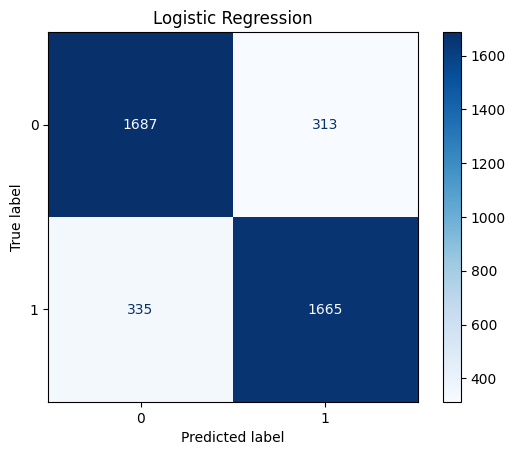

In [55]:
# Matriz de confusion
ConfusionMatrixDisplay.from_estimator(
    modelo_lr,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression")
plt.show()

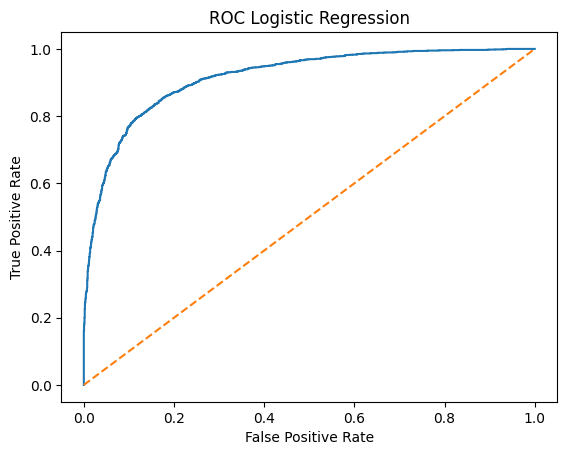

In [ ]:
# Curva ROC:
y_score = modelo_lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_score)

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Logistic Regression")

plt.show()

La curva ROC permite evaluar la capacidad del modelo para distinguir entre reseñas positivas y negativas considerando todos los posibles umbrales de decisión, en lugar de utilizar únicamente el valor por defecto de 0,5.



* Resultados MODELO 2: Multinomial Naive Bayes



In [ ]:
y_pred_nb = modelo_nb.predict(X_test)
print('Confussion matrix:\n{}'.format(confusion_matrix(y_test,  y_pred_nb)))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(
    y_test,
    y_pred_nb
))

Confussion matrix:
[[1646  354]
 [ 336 1664]]
Accuracy: 0.8275
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      2000
           1       0.82      0.83      0.83      2000

    accuracy                           0.83      4000
   macro avg       0.83      0.83      0.83      4000
weighted avg       0.83      0.83      0.83      4000



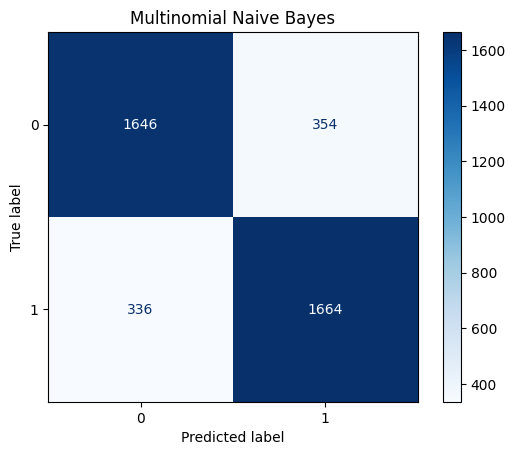

In [54]:
# Matriz de confusion
ConfusionMatrixDisplay.from_estimator(
    modelo_nb,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Multinomial Naive Bayes")
plt.show()

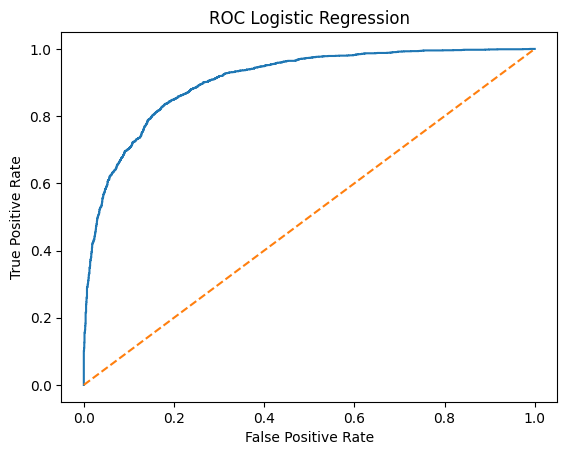

In [56]:
# Curva ROC:
y_score = modelo_nb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_score)

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Logistic Regression")

plt.show()

 Se han entrenado dos modelos diferentes para clasificar el sentimiento de las reviews: Logistic Regression y Multinomial Naive Bayes. Ambos modelos han obtenido resultados similares.

 Los resultados muestran que el modelo es capaz de clasificar correctamente la mayoría de las reseñas, aunque todavía existe un porcentaje de errores debido a la complejidad del lenguaje utilizado en las opiniones.

 Me quedo con el modelo 1 ya que esta ligeramente por encima que el modelo 2 en cuanto a resultados.

### Comparación de modelos

 Para comparar el rendimiento de los modelos entrenados se utilizan las métricas accuracy, precision, recall y f1-score.

| Modelo | Accuracy | Precision | Recall | F1-score |
|--------|----------|-----------|--------|----------|
| Logistic Regression | 0.838 | 0.84 | 0.84 | 0.84 |
| Multinomial Naive Bayes | 0.830 | 0.83 | 0.83 | 0.83 |